# ASSIGNMENT 06: RECURRENT NEURAL NETWORKS (RNN)
## Notebook 00: Các Khái Niệm Cơ Bản Về Mạng Nơ-ron Tái Phát (RNN Basic Concepts)

---

### Mục tiêu học tập của Notebook này:
Notebook này được thiết kế dành cho sinh viên mới tiếp cận với mạng nơ-ron tái phát (**Recurrent Neural Network - RNN**). Mục tiêu là xây dựng nền tảng tư duy vững chắc từ **bản chất toán học**, **cơ chế luân chuyển dữ liệu**, **cấu trúc tensor** cho tới **cách lập trình thực tế** trên cả hai framework phổ biến nhất hiện nay: **PyTorch** và **TensorFlow / Keras**.

> **Lưu ý quan trọng:** Notebook 00 chỉ tập trung vào lý thuyết nền tảng và các ví dụ minh họa trực quan độc lập. Không sử dụng dataset thực tế và không thay thế cho các Notebook thực nghiệm (01 – 04).

---

### Bảng Mục Lục Điều Hướng:
1. [RNN dùng để giải quyết vấn đề gì?](#section-1)
2. [Sequence và Time Step](#section-2)
3. [Công thức toán học của RNN](#section-3)
4. [Tính toán RNN bằng một ví dụ số nhỏ (Step-by-Step Walkthrough)](#section-4)
5. [Khái niệm Trải phẳng mạng qua thời gian (Unrolling RNN)](#section-5)
6. [RNN cho bài toán dự đoán chuỗi thời gian (Time-Series Forecasting)](#section-6)
7. [Tensor Shape trong RNN (PyTorch vs Keras)](#section-7)
8. [RNN trong PyTorch (`torch.nn.RNN`)](#section-8)
9. [RNN trong Keras (`SimpleRNN`)](#section-9)
10. [Quá trình Lan truyền xuôi (Forward Pass End-to-End)](#section-10)
11. [Hàm mất mát cho bài toán hồi quy (Loss Functions for Regression)](#section-11)
12. [Lan truyền ngược qua thời gian (Backpropagation Through Time - BPTT)](#section-12)
13. [Vấn đề Biến mất và Bùng nổ đạo hàm (Vanishing & Exploding Gradient)](#section-13)
14. [Bảng so sánh: RNN vs MLP](#section-14)
15. [RNN truyền thống vs LSTM và GRU](#section-15)
16. [Summary: What I need to remember before implementing RNN on real datasets](#section-16)


---
<a id="section-1"></a>
## 1. RNN dùng để giải quyết vấn đề gì?

### 1.1. Dữ liệu tuần tự (Sequential Data) là gì?
Trong học máy truyền thống, đa số các thuật toán giả định rằng các mẫu dữ liệu là **độc lập và cùng phân phối (i.i.d - independent and identically distributed)**. Ví dụ: khi dự đoán giá một căn nhà dựa trên diện tích và số phòng ngủ, thứ tự bạn đưa căn nhà A hay căn nhà B vào mô hình hoàn toàn không ảnh hưởng tới kết quả.

Tuy nhiên, trong thế giới thực có một lớp dữ liệu vô cùng quan trọng gọi là **Dữ liệu tuần tự (Sequential Data)**:
* **Định nghĩa**: Dữ liệu tuần tự là dạng dữ liệu mà trong đó **thứ tự xuất hiện của các phần tử mang thông tin quyết định ý nghĩa** (*Order matters*). Nếu ta xáo trộn hoặc hoán đổi vị trí của các quan sát, toàn bộ ngữ cảnh và ý nghĩa logic sẽ bị phá hủy.
* **Các dạng dữ liệu tuần tự điển hình**:
  1. *Chuỗi thời gian (Time Series)*: Các số đo biến thiên theo dòng thời gian liên tục (ví dụ: giá chứng khoán, doanh thu bán lẻ, nhiệt độ, điện tâm đồ ECG).
  2. *Văn bản tự nhiên (Natural Language / Text)*: Chuỗi các từ ngữ ghép lại thành câu. Ví dụ: *"Hôm nay trời không mưa, rất mát"* mang ý nghĩa hoàn toàn trái ngược với *"Hôm nay trời mưa, rất không mát"*.
  3. *Tín hiệu âm thanh (Audio/Speech)*: Biên độ sóng âm thay đổi theo từng mili-giây.
  4. *Chuỗi video (Video frames)*: Chuỗi các khung hình liên tiếp thể hiện hành động chuyển động.

### 1.2. Ví dụ thực tế về chuỗi thời gian
* **Giá cổ phiếu (Stock Prices)**: Giá đóng cửa của cổ phiếu Apple hôm nay ($t$) không phải là một con số ngẫu nhiên tách biệt. Các mức giá liền kề thường có quan hệ thống kê; khả năng dùng thông tin quá khứ để dự báo cần được kiểm tra trên dữ liệu tương lai và so với baseline.
* **Doanh số bán lẻ theo ngày (Daily Retail Sales)**: Có thể thay đổi theo thứ trong tuần và mùa mua sắm. Mức độ, chiều hướng và tính lặp lại của các mẫu hình này phụ thuộc từng dataset, cần được kiểm tra bằng dữ liệu.

### 1.3. Tại sao Mạng truyền thẳng (MLP thông thường) không xử lý tốt quan hệ theo thời gian?
Một mạng nơ-ron đa tầng truyền thẳng (**Multilayer Perceptron - MLP**) gặp 3 khác biệt về cấu trúc khi đối mặt với dữ liệu chuỗi:
1. **Cố định kích thước đầu vào (Fixed Input Dimension)**: MLP bắt buộc vector đầu vào phải có kích thước cố định $D$. Nhưng trong thực tế, các chuỗi dữ liệu có độ dài thay đổi linh hoạt (ví dụ: câu văn có thể dài 5 từ hoặc 30 từ; một phiên giao dịch có thể có số lượng quan sát khác nhau).
2. **Không có bộ nhớ trạng thái (Stateless / No Temporal Memory)**: MLP xử lý từng mẫu dữ liệu độc lập theo công thức $y = f(Wx + b)$. Nó không có cơ chế lưu lại thông tin của bước trước đó. Khi xử lý quan sát tại thời điểm $t_2$, nó hoàn toàn "quên" những gì đã xảy ra tại thời điểm $t_1$.
3. **Không chia sẻ trọng số qua thời gian (No Weight Sharing Across Time)**: Nếu ta cố tình ghép (flatten) một chuỗi $T$ bước vào một vector dài $[x_1, x_2, \dots, x_T]$ để nhét vào MLP, mỗi vị trí thời gian sẽ gắn với một nhóm trọng số hoàn toàn riêng biệt. Điều này dẫn đến sự bùng nổ số lượng tham số và không tự áp đặt tính chia sẻ trọng số qua thời gian (*temporal invariance*).

### 1.4. Ý tưởng "Memory" (Bộ nhớ trạng thái ẩn) của RNN
Mạng nơ-ron tái phát (**Recurrent Neural Network - RNN**) được sáng tạo để cung cấp cơ chế xử lý tuần tự và chia sẻ trọng số nhờ một ý tưởng mang tính đột phá: **Đưa vào vòng liên kết hồi quy (Recurrent Connection)**.

* Tại mỗi bước thời gian $t$, RNN nhận vào phần tử hiện tại $x_t$ đồng thời nhận thêm **trạng thái ẩn từ bước trước đó ($h_{t-1}$)**.
* Trạng thái ẩn $h_t$ đóng vai trò là một **vector bộ nhớ (memory / context vector)**, lưu giữ biểu diễn học được từ các đầu vào đến bước $t$; không bảo đảm giữ nguyên mọi thông tin quá khứ.
* Khi $x_t$ đến, mạng kết hợp ký ức $h_{t-1}$ với hiện tại $x_t$ để tạo thành ký ức mới $h_t$.
* Quá trình này lặp đi lặp lại như một dòng chảy thông tin xuyên suốt chiều dài của chuỗi.

> **Lưu ý**: MLP vẫn có thể dự báo chuỗi thời gian khi đầu vào chứa các độ trễ được sắp xếp đúng vị trí. RNN cung cấp một cấu trúc khác, không bảo đảm luôn tốt hơn MLP.


---
<a id="section-2"></a>
## 2. Sequence và Time Step

Để làm việc với RNN mà không bị nhầm lẫn, chúng ta cần phân biệt rõ ba khái niệm nền tảng:

### 2.1. Định nghĩa các khái niệm cốt lõi:
1. **Sequence (Chuỗi)**: Toàn bộ một chuỗi dữ liệu quan sát được xếp theo trình tự thời gian. 
   * Ký hiệu độ dài chuỗi là $T$ (thường gọi là `sequence_length`, `seq_len`, hoặc `time_steps`).
2. **Time Step (Bước thời gian)**: Một vị trí cụ thể trong chuỗi, đại diện cho một thời điểm đo lường $t \in \{1, 2, \dots, T\}$.
3. **Feature (Đặc trưng)**: Số lượng biến số được ghi nhận tại mỗi bước thời gian.
   * Ký hiệu là $D$ (hoặc `input_size`, `num_features`).
   * **Univariate (Đơn biến)**: $D = 1$ (chỉ đo 1 biến duy nhất tại mỗi thời điểm, ví dụ: chỉ ghi nhận Giá đóng cửa).
   * **Multivariate (Đa biến)**: $D > 1$ (đo nhiều chỉ số cùng lúc, ví dụ: [Giá mở cửa, Giá cao nhất, Giá thấp nhất, Giá đóng cửa, Khối lượng]).

---

### 2.2. Ví dụ số cụ thể minh họa
Giả sử ta theo dõi dữ liệu giao dịch cổ phiếu trong **3 ngày liên tiếp** ($T = 3$). Tại mỗi ngày, ta ghi nhận **2 đặc trưng**:
* Đặc trưng 1: Giá đóng cửa (USD)
* Đặc trưng 2: Khối lượng giao dịch (nghìn cổ phiếu)

Dữ liệu của chuỗi này bao gồm 3 time steps:
* **Time step 1 ($t=1$)**: $x_1 = [100.5, 120.0]$
* **Time step 2 ($t=2$)**: $x_2 = [102.0, 150.0]$
* **Time step 3 ($t=3$)**: $x_3 = [101.5, 110.0]$

Ma trận biểu diễn cho 1 chuỗi đơn lẻ có kích thước $(T, D) = (3, 2)$:
$$X = \begin{bmatrix} 100.5 & 120.0 \\ 102.0 & 150.0 \\ 101.5 & 110.0 \end{bmatrix}$$

Khi đưa vào huấn luyện mạng nơ-ron, ta không đưa từng chuỗi đơn lẻ mà gom nhiều chuỗi thành một **lô (batch)**. Do đó dữ liệu có dạng **3D Tensor**:
$$\text{Shape} = (\text{batch\_size}, \text{sequence\_length}, \text{input\_size}) = (N, T, D)$$


In [1]:
# Minh họa cấu trúc dữ liệu Sequence và 3D Tensor bằng NumPy
import numpy as np

# Tạo một sequence đơn lẻ: T = 3 time steps, D = 2 features
sample_sequence = np.array([
    [100.5, 120.0],  # t = 1: [Giá, Khối lượng]
    [102.0, 150.0],  # t = 2
    [101.5, 110.0]   # t = 3
], dtype=np.float32)

print("=== 1. CẤU TRÚC MỘT SEQUENCE ĐƠN LẺ ===")
print("Ma trận biểu diễn sequence:\n", sample_sequence)
print("Shape của một sequence (T, D):", sample_sequence.shape)
print(f"-> sequence_length (T) = {sample_sequence.shape[0]} bước thời gian")
print(f"-> input_size (D)       = {sample_sequence.shape[1]} đặc trưng mỗi bước\n")

# Giả lập một Mini-batch gồm 4 chuỗi dữ liệu khác nhau (batch_size N = 4)
# Kích thước 3D Tensor: (batch_size, sequence_length, input_size)
batch_size = 4
sequence_length = 3
input_size = 2

dummy_batch = np.stack([sample_sequence + i * 2.0 for i in range(batch_size)])

print("=== 2. CẤU TRÚC 3D TENSOR TRONG BATCHING ===")
print(f"Tensor Shape: (batch_size={batch_size}, sequence_length={sequence_length}, input_size={input_size})")
print(f"Shape thực tế của ndarray: {dummy_batch.shape}")
print("Nội dung của mẫu đầu tiên trong batch (index 0):\n", dummy_batch[0])


=== 1. CẤU TRÚC MỘT SEQUENCE ĐƠN LẺ ===
Ma trận biểu diễn sequence:
 [[100.5 120. ]
 [102.  150. ]
 [101.5 110. ]]
Shape của một sequence (T, D): (3, 2)
-> sequence_length (T) = 3 bước thời gian
-> input_size (D)       = 2 đặc trưng mỗi bước

=== 2. CẤU TRÚC 3D TENSOR TRONG BATCHING ===
Tensor Shape: (batch_size=4, sequence_length=3, input_size=2)
Shape thực tế của ndarray: (4, 3, 2)
Nội dung của mẫu đầu tiên trong batch (index 0):
 [[100.5 120. ]
 [102.  150. ]
 [101.5 110. ]]


---
<a id="section-3"></a>
## 3. Công thức toán học của RNN

Tại mỗi bước thời gian $t$, tế bào RNN cơ bản (Vanilla RNN Cell) thực hiện hai phép biến đổi tuyến tính kết hợp với hàm phi tuyến:

### 3.1. Phương trình cập nhật trạng thái ẩn (Hidden State Update):
$$h_t = \tanh(W_{xh} x_t + W_{hh} h_{t-1} + b_h)$$

Hoặc được viết gọn gàng dưới dạng ghép nối ma trận khối (Block Matrix Concatenation):
$$h_t = \tanh\left( [W_{xh} \mid W_{hh}] \begin{bmatrix} x_t \\ h_{t-1} \end{bmatrix} + b_h \right)$$

### 3.2. Phương trình tính đầu ra tại bước $t$ (Output Equation):
$$y_t = W_{hy} h_t + b_y$$

---

### 3.3. Bảng giải thích chi tiết từng thành phần toán học:

| Ký hiệu | Tên gọi | Kích thước ma trận / vector | Ý nghĩa toán học & vật lý |
| :--- | :--- | :--- | :--- |
| **$x_t$** | Vector đầu vào hiện tại | $(D \times 1)$ | Giá trị của các đặc trưng tại bước thời gian $t$. $D = \text{input\_size}$. |
| **$h_{t-1}$** | Vector trạng thái ẩn quá khứ | $(H \times 1)$ | Ký ức tóm tắt từ bước $1$ đến $t-1$. $h_0$ ban đầu thường được gán bằng vector $0$ ($\mathbf{0}$). |
| **$h_t$** | Vector trạng thái ẩn hiện tại | $(H \times 1)$ | Ký ức mới tại thời điểm $t$, chứa thông tin kết hợp giữa quá khứ $h_{t-1}$ và hiện tại $x_t$. $H = \text{hidden\_size}$. |
| **$W_{xh}$** | Ma trận trọng số Input-to-Hidden | $(H \times D)$ | Chiếu vector đầu vào từ không gian $D$ chiều sang không gian ẩn $H$ chiều. |
| **$W_{hh}$** | Ma trận trọng số Hidden-to-Hidden | $(H \times H)$ | Trọng số hồi quy (recurrent weights), quy định mức độ chuyển giao ký ức từ $h_{t-1}$ sang $h_t$. |
| **$b_h$** | Vector bias của hidden state | $(H \times 1)$ | Độ dịch chuyển (bias) giúp điều chỉnh ngưỡng kích hoạt của trạng thái ẩn. |
| **$\tanh$** | Hàm kích hoạt Hyperbolic Tangent | Phép tính vô hướng từng phần tử | Công thức: $\tanh(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}}$. Nén mọi giá trị vào khoảng $(-1, 1)$, giữ cho độ lớn của trạng thái ẩn không bị bùng nổ vô hạn qua thời gian. |
| **$W_{hy}$** | Ma trận trọng số Hidden-to-Output | $(O \times H)$ | Chiếu từ không gian ẩn $H$ chiều sang không gian đầu ra $O$ chiều ($O = \text{output\_size}$). |
| **$b_y$** | Vector bias của output | $(O \times 1)$ | Độ lệch cho giá trị dự đoán đầu ra. |
| **$y_t$** | Vector đầu ra tại bước $t$ | $(O \times 1)$ | Dự đoán tại bước $t$. Trong bài toán dự báo một bước tiếp theo (many-to-one), ta chỉ lấy $y_T$ tại bước cuối cùng. |


---
<a id="section-4"></a>
## 4. Tính toán RNN bằng một ví dụ số nhỏ (Step-by-Step Manual Walkthrough)

Để hiểu cặn kẽ cách một tế bào RNN truyền trạng thái ẩn qua các bước thời gian, chúng ta sẽ cùng giải một **ví dụ số cực nhỏ bằng tay**, sau đó kiểm chứng lại bằng code Python.

### 4.1. Thiết lập bài toán:
* Đầu vào là một chuỗi có $T = 3$ time steps, mỗi time step có 1 đặc trưng ($D = 1$):
  $$x_1 = 1.0, \quad x_2 = 2.0, \quad x_3 = 0.5$$
* Kích thước trạng thái ẩn: $H = 1$ (chỉ là 1 số thực vô hướng để dễ tính nhẩm)
* Kích thước đầu ra: $O = 1$
* Các trọng số và bias được giả định cụ thể như sau:
  $$W_{xh} = 0.5, \quad W_{hh} = 0.8, \quad b_h = 0.0$$
  $$W_{hy} = 1.2, \quad b_y = 0.1$$
* Khởi tạo trạng thái ẩn ban đầu: $h_0 = 0.0$

---

### 4.2. Tính toán chi tiết từng bước thời gian:

#### **Bước 1: Time step $t = 1$ (Input $x_1 = 1.0$)**
1. Tính tổng tuyến tính đầu vào của hidden state:
   $$z_1 = W_{xh} \cdot x_1 + W_{hh} \cdot h_0 + b_h = 0.5 \times 1.0 + 0.8 \times 0.0 + 0.0 = 0.5000$$
2. Áp dụng hàm kích hoạt $\tanh$:
   $$h_1 = \tanh(z_1) = \tanh(0.5000) \approx 0.4621$$
3. Tính đầu ra tại thời điểm $t=1$:
   $$y_1 = W_{hy} \cdot h_1 + b_y = 1.2 \times 0.4621 + 0.1 = 0.5545 + 0.1 = 0.6545$$

#### **Bước 2: Time step $t = 2$ (Input $x_2 = 2.0$, Ký ức nhận vào $h_1 = 0.4621$)**
1. Tính tổng tuyến tính:
   $$z_2 = W_{xh} \cdot x_2 + W_{hh} \cdot h_1 + b_h = 0.5 \times 2.0 + 0.8 \times 0.4621 + 0.0 = 1.0 + 0.3697 = 1.3697$$
2. Áp dụng hàm $\tanh$:
   $$h_2 = \tanh(z_2) = \tanh(1.3697) \approx 0.8786$$
3. Tính đầu ra tại thời điểm $t=2$:
   $$y_2 = W_{hy} \cdot h_2 + b_y = 1.2 \times 0.8786 + 0.1 = 1.0543 + 0.1 = 1.1543$$

#### **Bước 3: Time step $t = 3$ (Input $x_3 = 0.5$, Ký ức nhận vào $h_2 = 0.8786$)**
1. Tính tổng tuyến tính:
   $$z_3 = W_{xh} \cdot x_3 + W_{hh} \cdot h_2 + b_h = 0.5 \times 0.5 + 0.8 \times 0.8786 + 0.0 = 0.25 + 0.7029 = 0.9529$$
2. Áp dụng hàm $\tanh$:
   $$h_3 = \tanh(z_3) = \tanh(0.9529) \approx 0.7411$$
3. Tính đầu ra tại thời điểm $t=3$:
   $$y_3 = W_{hy} \cdot h_3 + b_y = 1.2 \times 0.7411 + 0.1 = 0.8893 + 0.1 = 0.9893$$

> **Bản chất rút ra:**
> Hãy quan sát cách tính $z_3$: giá trị $0.9529$ được tạo nên bởi $0.25$ (từ đầu vào hiện tại $x_3$) cộng với $0.7029$ (thừa hưởng từ $h_2$, vốn dĩ $h_2$ lại chứa thông tin của $x_2$ và $x_1$). RNN thực sự đã nén toàn bộ chuỗi quá khứ vào vector $h_3$!


In [2]:
# Tái hiện chính xác ví dụ số nhỏ trên bằng code Python thuần (NumPy)
import numpy as np

# Định nghĩa chuỗi đầu vào x: 3 time steps
x_seq = [1.0, 2.0, 0.5]

# Định nghĩa các trọng số và bias
W_xh = 0.5
W_hh = 0.8
b_h  = 0.0

W_hy = 1.2
b_y  = 0.1

# Trạng thái ẩn khởi tạo
h = 0.0

print(f"{'Time step t':<12} | {'Input x_t':<10} | {'Linear z_t':<12} | {'Hidden h_t':<12} | {'Output y_t':<12}")
print("-" * 68)

for t, x_t in enumerate(x_seq, start=1):
    # 1. Linear combination: z_t = W_xh * x_t + W_hh * h_{t-1} + b_h
    z_t = W_xh * x_t + W_hh * h + b_h
    
    # 2. Activation: h_t = tanh(z_t)
    h_new = np.tanh(z_t)
    
    # 3. Output: y_t = W_hy * h_t + b_y
    y_t = W_hy * h_new + b_y
    
    print(f"Step {t:<7} | {x_t:<10.4f} | {z_t:<12.4f} | {h_new:<12.4f} | {y_t:<12.4f}")
    
    # Cập nhật hidden state cho bước tiếp theo
    h = h_new

print("-" * 68)
print("-> Code giữ độ chính xác đầy đủ; phần tính tay làm tròn đến 4 chữ số thập phân.")


Time step t  | Input x_t  | Linear z_t   | Hidden h_t   | Output y_t  
--------------------------------------------------------------------
Step 1       | 1.0000     | 0.5000       | 0.4621       | 0.6545      
Step 2       | 2.0000     | 1.3697       | 0.8786       | 1.1543      
Step 3       | 0.5000     | 0.9529       | 0.7411       | 0.9893      
--------------------------------------------------------------------
-> Code giữ độ chính xác đầy đủ; phần tính tay làm tròn đến 4 chữ số thập phân.


---
<a id="section-5"></a>
## 5. Unrolling RNN (Trải phẳng mạng qua thời gian)

### 5.1. Hai góc nhìn về kiến trúc RNN:
Mạng RNN có thể được biểu diễn dưới hai góc nhìn tương đương:
1. **Dạng gấp (Folded / Compact Representation)**: Một tế bào nơ-ron duy nhất nhận vector $x_t$, tính ra $h_t$, và có một mũi tên tự hồi quy (self-loop) mang trọng số $W_{hh}$ quay trở lại chính nó.
2. **Dạng trải phẳng theo thời gian (Unrolled / Unfolded Representation)**: Ta "duỗi thẳng" vòng lặp hồi quy theo trục thời gian $t = 1, 2, \dots, T$. Khi đó, RNN trông như một mạng nơ-ron sâu nhiều tầng xếp nối tiếp nhau, trong đó tầng sau nhận output của tầng trước.

```text
    DẠNG GẤP (FOLDED)                    DẠNG TRẢI PHẲNG QUA THỜI GIAN (UNROLLED)
         [ y_t ]                              [ y_1 ]         [ y_2 ]         [ y_3 ]
            ^                                    ^               ^               ^
            | W_hy                               | W_hy          | W_hy          | W_hy
     +------+------+                      +------+------+ +------+------+ +------+------+
  +->|  RNN Cell   |--+ W_hh       h_0=0  |  RNN Cell   | |  RNN Cell   | |  RNN Cell   |
  |  +------+------+  |          -------> |   (t = 1)   |->|   (t = 2)   |->|   (t = 3)   |
  +---------+---------+                   +------+------+ |+------+------+ +------+------+
            ^                                    ^   h_1         ^   h_2         ^   h_3
            | W_xh                               | W_xh          | W_xh          | W_xh
         [ x_t ]                              [ x_1 ]         [ x_2 ]         [ x_3 ]
```

---

### 5.2. Nguyên lý then chốt: Chia sẻ trọng số (Weight Sharing)
Một trong những đặc tính quan trọng nhất của RNN là **Chia sẻ trọng số qua mọi time step**:
* Tại bước $t = 1$, mô hình sử dụng bộ trọng số $\{W_{xh}, W_{hh}, W_{hy}, b_h, b_y\}$.
* Tại bước $t = 2$, mô hình sử dụng **CHÍNH XÁC CÙNG BỘ TRỌNG SỐ** $\{W_{xh}, W_{hh}, W_{hy}, b_h, b_y\}$.
* Tại bước $t = T$, mô hình vẫn sử dụng bộ trọng số đó!

> **Ý nghĩa thực tiễn to lớn:**
> 1. Số lượng tham số (weights) của RNN **hoàn toàn cố định**, không hề tăng lên khi chuỗi dữ liệu dài ra từ 10 bước lên 1000 bước.
> 2. Cho phép mạng học được các quy luật mẫu (patterns) bất kể quy luật đó xuất hiện ở đầu chuỗi, giữa chuỗi hay cuối chuỗi.


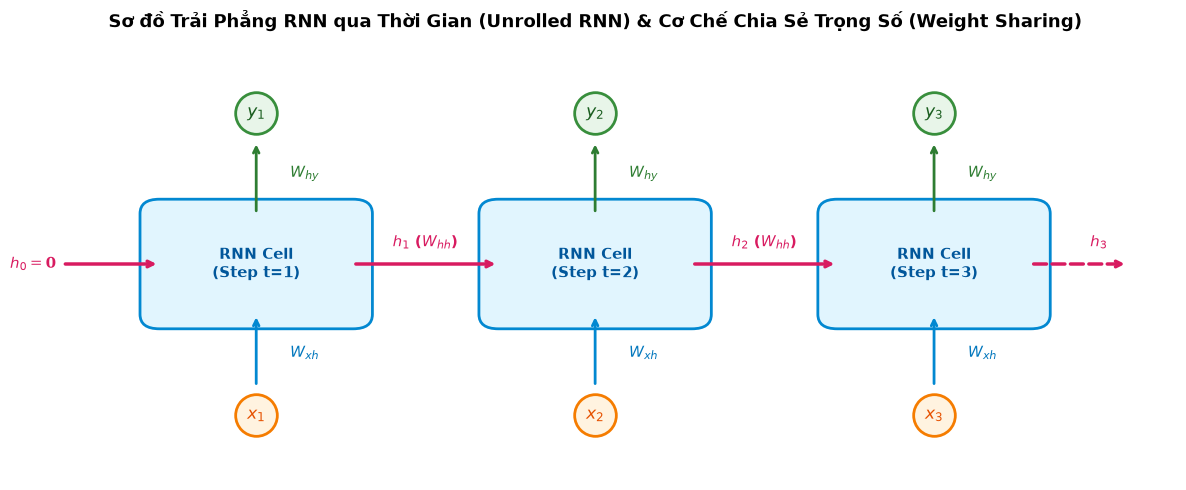

In [3]:
# Trực quan hóa sơ đồ Unrolling RNN bằng Matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(12, 5))
ax.set_xlim(-1, 11)
ax.set_ylim(-0.5, 5.5)
ax.axis('off')

# Màu sắc trực quan
box_color = '#E1F5FE'
box_border = '#0288D1'
node_color = '#FFF3E0'
node_border = '#F57C00'

# Vẽ 3 bước thời gian: t=1, t=2, t=3
steps = [1, 2, 3]
x_offsets = [1.5, 5.0, 8.5]

for i, (t, x_pos) in enumerate(zip(steps, x_offsets)):
    # 1. Hộp RNN Cell
    rect = patches.FancyBboxPatch((x_pos - 1.0, 1.8), 2.0, 1.4, boxstyle="round,pad=0.2",
                                  edgecolor=box_border, facecolor=box_color, linewidth=2)
    ax.add_patch(rect)
    ax.text(x_pos, 2.5, f"RNN Cell\n(Step t={t})", ha="center", va="center", fontsize=11, fontweight='bold', color='#01579B')
    
    # 2. Input x_t (phía dưới)
    ax.scatter(x_pos, 0.4, s=900, color=node_color, edgecolors=node_border, linewidth=2, zorder=3)
    ax.text(x_pos, 0.4, f"$x_{t}$", ha="center", va="center", fontsize=12, fontweight='bold', color='#E65100')
    
    # Mũi tên x_t -> RNN Cell (W_xh)
    ax.annotate('', xy=(x_pos, 1.8), xytext=(x_pos, 0.8),
                arrowprops=dict(arrowstyle="->", color="#0288D1", lw=2))
    ax.text(x_pos + 0.35, 1.2, "$W_{xh}$", fontsize=11, color='#0277BD', fontweight='bold')
    
    # 3. Output y_t (phía trên)
    ax.scatter(x_pos, 4.6, s=900, color='#E8F5E9', edgecolors='#388E3C', linewidth=2, zorder=3)
    ax.text(x_pos, 4.6, f"$y_{t}$", ha="center", va="center", fontsize=12, fontweight='bold', color='#1B5E20')
    
    # Mũi tên RNN Cell -> y_t (W_hy)
    ax.annotate('', xy=(x_pos, 4.2), xytext=(x_pos, 3.2),
                arrowprops=dict(arrowstyle="->", color="#2E7D32", lw=2))
    ax.text(x_pos + 0.35, 3.7, "$W_{hy}$", fontsize=11, color='#2E7D32', fontweight='bold')

# 4. Mũi tên truyền hidden state h_{t-1} -> h_t
# h_0 -> Cell 1
ax.annotate('', xy=(0.5, 2.5), xytext=(-0.5, 2.5),
            arrowprops=dict(arrowstyle="->", color="#D81B60", lw=2.5))
ax.text(-0.8, 2.5, "$h_0=\\mathbf{0}$", ha="center", va="center", fontsize=11, color="#D81B60", fontweight='bold')

# Cell 1 -> Cell 2
ax.annotate('', xy=(4.0, 2.5), xytext=(2.5, 2.5),
            arrowprops=dict(arrowstyle="->", color="#D81B60", lw=2.5))
ax.text(3.25, 2.8, "$h_1$ ($W_{hh}$)", ha="center", va="center", fontsize=11, color="#D81B60", fontweight='bold')

# Cell 2 -> Cell 3
ax.annotate('', xy=(7.5, 2.5), xytext=(6.0, 2.5),
            arrowprops=dict(arrowstyle="->", color="#D81B60", lw=2.5))
ax.text(6.75, 2.8, "$h_2$ ($W_{hh}$)", ha="center", va="center", fontsize=11, color="#D81B60", fontweight='bold')

# Cell 3 -> tiếp tục
ax.annotate('', xy=(10.5, 2.5), xytext=(9.5, 2.5),
            arrowprops=dict(arrowstyle="->", color="#D81B60", lw=2.5, linestyle="dashed"))
ax.text(10.2, 2.8, "$h_3$", ha="center", va="center", fontsize=11, color="#D81B60", fontweight='bold')

plt.title("Sơ đồ Trải Phẳng RNN qua Thời Gian (Unrolled RNN) & Cơ Chế Chia Sẻ Trọng Số (Weight Sharing)",
          fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


---
<a id="section-6"></a>
## 6. RNN cho bài toán dự đoán chuỗi thời gian (Time-Series Forecasting)

Trong bài toán thực tế, dữ liệu thu thập ban đầu thường là một mảng 1 chiều liên tục:
$$S = [s_1, s_2, s_3, s_4, s_5, s_6, s_7, s_8, \dots, s_N]$$

Làm thế nào để chuyển đổi chuỗi 1 chiều này thành tập dữ liệu mẫu gồm các cặp **(Đặc trưng đầu vào $X$, Nhãn mục tiêu $y$)** để nạp vào mạng RNN? Phương pháp chuẩn hóa được sử dụng là **Kỹ thuật Cửa sổ trượt (Sliding Window)**.

---

### 6.1. Cơ chế Cửa sổ trượt (Sliding Window)
Giả sử ta chọn kích thước cửa sổ quá khứ là **$L = 5$ (Lookback / Window size = 5)**:
* Ta muốn dùng thông tin của 5 ngày liên tiếp trong quá khứ để dự đoán giá trị của ngày thứ 6 tiếp theo (*One-step-ahead forecasting*).
* Cửa sổ sẽ trượt dần từ đầu chuỗi đến cuối chuỗi:

$$\begin{array}{l|ccccc|c}
\text{Mẫu dữ liệu} & \text{Bước } t_1 & \text{Bước } t_2 & \text{Bước } t_3 & \text{Bước } t_4 & \text{Bước } t_5 & \text{Target } y \\
\hline
\text{Sample 1} & s_1 & s_2 & s_3 & s_4 & s_5 & \mathbf{s_6} \\
\text{Sample 2} & s_2 & s_3 & s_4 & s_5 & s_6 & \mathbf{s_7} \\
\text{Sample 3} & s_3 & s_4 & s_5 & s_6 & s_7 & \mathbf{s_8} \\
\text{Sample } i & s_i & s_{i+1} & s_{i+2} & s_{i+3} & s_{i+4} & \mathbf{s_{i+5}} \\
\end{array}$$

* Sau khi trượt hết chuỗi độ dài $N$:
  * Tập input $X$ sẽ có số lượng mẫu là $M = N - L$.
  * Mỗi mẫu trong $X$ là một ma trận kích thước $(L, D)$.
  * Mỗi nhãn $y$ là giá trị mục tiêu vô hướng (scalar).


In [4]:
# Xây dựng hàm tạo Sliding Window chuẩn bằng NumPy
import numpy as np

def create_sliding_windows(series, window_size):
    """
    Chuyển chuỗi 1D thành cặp ma trận (X, y) theo phương pháp sliding window.
    
    Tham số:
        series (np.ndarray): Dữ liệu chuỗi 1 chiều độ dài N.
        window_size (int): Độ dài cửa sổ quan sát quá khứ (L).
        
    Trả về:
        X (np.ndarray): Mảng 3D shape (N - window_size, window_size, 1)
        y (np.ndarray): Mảng 1D shape (N - window_size,)
    """
    X, y = [], []
    for i in range(len(series) - window_size):
        # Lấy window_size bước liên tiếp làm input
        window = series[i : i + window_size]
        # Lấy phần tử ngay kế tiếp làm nhãn mục tiêu
        target = series[i + window_size]
        X.append(window)
        y.append(target)
        
    # Reshape X thành 3D: (num_samples, window_size, 1) cho bài toán đơn biến
    return np.array(X)[..., np.newaxis], np.array(y)

# Thử nghiệm với một chuỗi giá trị số đơn giản gồm 8 ngày
raw_prices = np.array([10.0, 20.0, 30.0, 40.0, 50.0, 60.0, 70.0, 80.0])
window_size = 5

X_data, y_data = create_sliding_windows(raw_prices, window_size=window_size)

print("Chuỗi dữ liệu gốc:", raw_prices)
print(f"Window size = {window_size}\n")

print(f"{'Mẫu thứ':<10} | {'Input Sequence (X)':<30} | {'Target (y)':<10}")
print("-" * 56)
for idx, (x_sample, y_sample) in enumerate(zip(X_data, y_data)):
    x_flatten = x_sample.squeeze().tolist()
    print(f"Sample {idx:<3} | {str(x_flatten):<30} | {y_sample:<10.1f}")

print("-" * 56)
print("Shape của toàn bộ tập X:", X_data.shape, "-> (num_samples, sequence_length, input_size)")
print("Shape của toàn bộ tập y:", y_data.shape, "-> (num_samples,)")


Chuỗi dữ liệu gốc: [10. 20. 30. 40. 50. 60. 70. 80.]
Window size = 5

Mẫu thứ    | Input Sequence (X)             | Target (y)
--------------------------------------------------------
Sample 0   | [10.0, 20.0, 30.0, 40.0, 50.0] | 60.0      
Sample 1   | [20.0, 30.0, 40.0, 50.0, 60.0] | 70.0      
Sample 2   | [30.0, 40.0, 50.0, 60.0, 70.0] | 80.0      
--------------------------------------------------------
Shape của toàn bộ tập X: (3, 5, 1) -> (num_samples, sequence_length, input_size)
Shape của toàn bộ tập y: (3,) -> (num_samples,)


---
<a id="section-7"></a>
## 7. Tensor Shape trong RNN

Kích thước của dữ liệu (Tensor Shape) là nguyên nhân gây ra nhiều lỗi nhất cho người mới bắt đầu lập trình Deep Learning với RNN. Hãy cùng phân tích cặn kẽ chuẩn 3D Tensor:

### 7.1. Cấu trúc 3 chiều chuẩn: `(batch_size, sequence_length, input_size)`
Xét một Tensor có kích thước cụ thể: **`(32, 10, 1)`**:

1. **`batch_size = 32` (Chiều số 0)**:
   * Số lượng chuỗi con độc lập được nạp đồng thời vào GPU/CPU trong một lượt lan truyền xuôi (mini-batch).
   * Thay vì huấn luyện từng chuỗi một, ta gom 32 chuỗi để tính toán song song, giúp tăng tốc độ huấn luyện và ổn định gradient.
2. **`sequence_length = 10` (Chiều số 1)**:
   * Độ dài của mỗi chuỗi con (số bước thời gian / time steps).
   * Ví dụ: Mô hình quan sát 10 ngày giao dịch liên tiếp để đưa ra dự báo.
3. **`input_size = 1` (Chiều số 2)**:
   * Số lượng đặc trưng được đo lường tại mỗi time step.
   * Nếu chỉ sử dụng giá đóng cửa `Close`, thì `input_size = 1`.
   * Nếu đưa thêm các chỉ báo kỹ thuật như `[Open, High, Low, Close, Volume]`, thì `input_size = 5`. Khi đó shape trở thành `(32, 10, 5)`.

---

### 7.2. So sánh chuẩn Shape giữa PyTorch và Keras / TensorFlow:

| Đặc tính so sánh | Keras / TensorFlow (`SimpleRNN`) | PyTorch (`torch.nn.RNN`) |
| :--- | :--- | :--- |
| **Định dạng mặc định** | `(batch_size, sequence_length, input_size)` | `(sequence_length, batch_size, input_size)` *(Mặc định gốc)* |
| **Tùy chọn cấu hình** | Luôn mặc định Batch-first | Cần đặt cờ **`batch_first=True`** |
| **Lời khuyên thực tiễn** | Đồng nhất và tự nhiên với tư duy lập trình | **LUÔN LUÔN khai báo `batch_first=True`** trong PyTorch để đồng nhất với NumPy và Keras |
| **Hidden State ($h_n$)** | Tự quản lý bên trong, chỉ trả về nếu bật `return_state=True` | Luôn trả về riêng: Shape `(num_layers, batch_size, hidden_size)` |
| **Output khi lấy mọi bước** | `return_sequences=True` $\to$ `(batch, seq_len, units)` | Tensor `out` $\to$ `(batch, seq_len, hidden_size)` (với `batch_first=True`) |
| **Output khi chỉ lấy bước cuối** | `return_sequences=False` $\to$ `(batch, units)` | Trích xuất thủ công: `out[:, -1, :]` hoặc dùng `h_n[-1]` $\to$ `(batch, hidden_size)` |


---
<a id="section-8"></a>
## 8. RNN trong PyTorch (`torch.nn.RNN`)

Trong PyTorch, lớp `torch.nn.RNN` cho phép ta tạo một tầng mạng hồi quy hoàn chỉnh chỉ với vài dòng code. 

### 8.1. Các tham số khởi tạo quan trọng:
* `input_size`: Số đặc trưng đầu vào tại mỗi bước thời gian ($D$).
* `hidden_size`: Số nơ-ron trong trạng thái ẩn ($H$).
* `num_layers`: Số lượng tầng RNN xếp chồng lên nhau (mặc định là 1).
* `batch_first=True`: Quy định tensor đầu vào có dạng `(batch, seq_len, input_size)`.

### 8.2. Giá trị trả về của `torch.nn.RNN`:
Khi truyền một tensor $x$ qua `rnn(x)`, PyTorch trả về một tuple gồm 2 thành phần: `out, h_n = rnn(x)`:
1. **`out` (Output Tensor)**: Chứa toàn bộ các trạng thái ẩn tại **mọi time step** của tầng RNN trên cùng:
   $$\text{Shape: } (\text{batch\_size}, \text{sequence\_length}, \text{hidden\_size})$$
2. **`h_n` (Final Hidden State)**: Chứa trạng thái ẩn tại **time step cuối cùng** ($t = T$) của từng tầng:
   $$\text{Shape: } (\text{num\_layers}, \text{batch\_size}, \text{hidden\_size})$$


In [5]:
# Xây dựng và kiểm tra mô hình RNN bằng PyTorch
import torch
import torch.nn as nn

# Thiết lập seed để kết quả có thể tái lập
torch.manual_seed(42)

# Cấu hình các siêu tham số
batch_size = 32
seq_len = 10
input_size = 1
hidden_size = 16

# 1. Khởi tạo tầng RNN với batch_first=True
rnn_layer = nn.RNN(input_size=input_size, hidden_size=hidden_size, num_layers=1, batch_first=True)

# 2. Tạo tensor đầu vào giả lập: shape (32, 10, 1)
dummy_x = torch.randn(batch_size, seq_len, input_size)

# 3. Chạy forward pass qua rnn_layer
# Nếu không truyền h_0, PyTorch sẽ tự động khởi tạo h_0 là vector toàn số 0
out, h_n = rnn_layer(dummy_x)

print("=== KẾT QUẢ FORWARD PASS TRONG PYTORCH ===")
print(f"1. Input shape  (x)   : {dummy_x.shape}  -> (batch_size, seq_len, input_size)")
print(f"2. Output shape (out) : {out.shape} -> (batch_size, seq_len, hidden_size)")
print(f"3. Hidden shape (h_n) : {h_n.shape}   -> (num_layers, batch_size, hidden_size)\n")

# 4. Kiểm chứng tính logic:
# Trạng thái ẩn tại bước thời gian cuối cùng của `out` (tức out[:, -1, :])
# phải hoàn toàn trùng khớp với `h_n[0]` (với mô hình 1 layer).
last_step_out = out[:, -1, :]
is_identical = torch.allclose(last_step_out, h_n[0], atol=1e-6)
print(f"Kiểm chứng out[:, -1, :] có trùng khớp với h_n[0] không? -> {is_identical}")


=== KẾT QUẢ FORWARD PASS TRONG PYTORCH ===
1. Input shape  (x)   : torch.Size([32, 10, 1])  -> (batch_size, seq_len, input_size)
2. Output shape (out) : torch.Size([32, 10, 16]) -> (batch_size, seq_len, hidden_size)
3. Hidden shape (h_n) : torch.Size([1, 32, 16])   -> (num_layers, batch_size, hidden_size)

Kiểm chứng out[:, -1, :] có trùng khớp với h_n[0] không? -> True


---
<a id="section-9"></a>
## 9. RNN trong Keras (`SimpleRNN`)

Trong hệ sinh thái Keras / TensorFlow, lớp tương ứng là `SimpleRNN` (hoặc `tf.keras.layers.SimpleRNN`). 

### 9.1. Điểm cần ghi nhớ về tham số `return_sequences`:
* **`return_sequences=False` (Mặc định)**:
  * Mô hình chỉ trả về trạng thái ẩn tại **bước thời gian cuối cùng** ($h_T$).
  * Tensor đầu ra có dạng 2D: `(batch_size, units)`.
  * Thường dùng ở tầng RNN cuối cùng trước khi nối vào lớp `Dense(1)` để đưa ra một giá trị dự báo duy nhất.
* **`return_sequences=True`**:
  * Mô hình trả về trạng thái ẩn tại **toàn bộ các bước thời gian** ($h_1, h_2, \dots, h_T$).
  * Tensor đầu ra có dạng 3D: `(batch_size, sequence_length, units)`.
  * **BẮT BUỘC** phải bật cờ này nếu bạn muốn xếp chồng (stack) một tầng RNN khác ngay sau nó!


In [6]:
# Xây dựng và kiểm tra mô hình Keras SimpleRNN
import os
import numpy as np

# Đảm bảo Keras hoạt động trơn tru trên mọi nền tảng
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import SimpleRNN, Dense, Input
    print(f"Sử dụng TensorFlow {tf.__version__}")
except ImportError:
    # Nếu chạy trong môi trường Keras 3 độc lập với PyTorch backend
    os.environ["KERAS_BACKEND"] = "torch"
    import keras
    from keras.models import Sequential
    from keras.layers import SimpleRNN, Dense, Input
    print(f"Sử dụng Keras {keras.__version__} (PyTorch Backend)")

import keras
keras.utils.set_random_seed(42)

# Tạo dummy input tương đương: batch 32, seq_len 10, input_size 1
dummy_x_keras = np.random.randn(32, 10, 1).astype(np.float32)

# Trường hợp A: return_sequences=False (Mô hình tiêu chuẩn cho dự báo giá trị kế tiếp)
model_single = Sequential([
    Input(shape=(10, 1)),
    SimpleRNN(units=16, return_sequences=False, name="rnn_last_step"),
    Dense(units=1, name="regressor_output")
], name="RNN_Many_To_One")

out_single = model_single(dummy_x_keras)

print("=== MÔ HÌNH A: return_sequences=False ===")
print("Input shape       :", dummy_x_keras.shape)
print("Output shape      :", out_single.shape, "-> (batch_size, output_size)")
model_single.summary()

# Trường hợp B: return_sequences=True (Xếp chồng nhiều tầng RNN)
model_stacked = Sequential([
    Input(shape=(10, 1)),
    SimpleRNN(units=16, return_sequences=True, name="rnn_layer_1"),   # Trả về 3D (32, 10, 16)
    SimpleRNN(units=8, return_sequences=False, name="rnn_layer_2"),   # Trả về 2D (32, 8)
    Dense(units=1, name="final_dense")
], name="Stacked_RNN")

out_stacked = model_stacked(dummy_x_keras)
print("\n=== MÔ HÌNH B: Stacked RNN (return_sequences=True -> False) ===")
print("Output shape của mô hình xếp chồng:", out_stacked.shape)


Sử dụng TensorFlow 2.21.0


=== MÔ HÌNH A: return_sequences=False ===
Input shape       : (32, 10, 1)
Output shape      : (32, 1) -> (batch_size, output_size)


Model: "RNN_Many_To_One"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rnn_last_step (SimpleRNN)       │ (None, 16)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ regressor_output (Dense)        │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 305 (1.19 KB)

 Trainable params: 305 (1.19 KB)

 Non-trainable params: 0 (0.00 B)


=== MÔ HÌNH B: Stacked RNN (return_sequences=True -> False) ===
Output shape của mô hình xếp chồng: (32, 1)


---
<a id="section-10"></a>
## 10. Forward Pass End-to-End (Quy trình Lan truyền xuôi hoàn chỉnh)

Trong một bài toán hồi quy chuỗi thời gian (ví dụ dự đoán giá cổ phiếu ngày tiếp theo), luồng dữ liệu truyền qua mạng nơ-ron từ đầu đến cuối diễn ra qua các chặng sau:

$$\text{Input } X \in \mathbb{R}^{B \times T \times D} \xrightarrow{\text{RNN Cell}} \text{All Hidden States } h_{1:T} \in \mathbb{R}^{B \times T \times H} \xrightarrow{\text{Select Last Step }} h_T \in \mathbb{R}^{B \times H} \xrightarrow{\text{Linear Layer}} \hat{y} \in \mathbb{R}^{B \times 1}$$

### Chi tiết các bước thực thi:
1. **Chặng 1 - Nhận đầu vào**: Nhận lô dữ liệu $X$ kích thước `(batch_size, sequence_length, input_size)`.
2. **Chặng 2 - Cập nhật trạng thái ẩn**: Tế bào RNN lặp qua từng bước thời gian $t = 1, \dots, T$, tính toán và cập nhật $h_t$ dựa trên $x_t$ và $h_{t-1}$.
3. **Chặng 3 - Trích xuất trạng thái cuối cùng**: Vì ta dự báo giá trị sau chuỗi $T$ bước, ta trích xuất trạng thái ẩn tại bước thời gian cuối cùng: $h_T = \text{out}[:, -1, :]$. Vector này chứa toàn bộ bản tóm tắt thông tin của chuỗi quá khứ.
4. **Chặng 4 - Dự đoán (Linear Projection)**: Đưa $h_T$ qua một lớp Fully Connected (`Linear(hidden_size, 1)`) để tính toán giá trị đầu ra scalar $\hat{y}$.


In [7]:
# Xây dựng một Module PyTorch hoàn chỉnh thực hiện Forward Pass End-to-End
import torch
import torch.nn as nn

class SimpleRNNRegressor(nn.Module):
    def __init__(self, input_size=1, hidden_size=16, output_size=1):
        super(SimpleRNNRegressor, self).__init__()
        
        # Tầng RNN chính với batch_first=True
        self.rnn = nn.RNN(input_size=input_size, 
                          hidden_size=hidden_size, 
                          num_layers=1, 
                          batch_first=True)
        
        # Tầng Fully Connected chiếu từ hidden state sang giá trị dự đoán
        self.fc = nn.Linear(hidden_size, output_size)
        
    def forward(self, x):
        # 1. Truyền x qua RNN layer
        # out shape: (batch_size, seq_len, hidden_size)
        out, h_n = self.rnn(x)
        
        # 2. Lấy hidden state tại bước thời gian cuối cùng: t = -1
        # last_step shape: (batch_size, hidden_size)
        last_step = out[:, -1, :]
        
        # 3. Dự đoán qua lớp Linear
        # y_hat shape: (batch_size, output_size)
        y_hat = self.fc(last_step)
        
        return y_hat, out

# Kiểm thử với một batch nhỏ
torch.manual_seed(100)
model = SimpleRNNRegressor(input_size=1, hidden_size=16, output_size=1)

# Giả lập 8 mẫu chuỗi, mỗi chuỗi dài 5 ngày, 1 đặc trưng
test_input = torch.randn(8, 5, 1)
y_pred, all_hiddens = model(test_input)

print("=== QUÁ TRÌNH FORWARD PASS QUA TỪNG BƯỚC ===")
print("1. Shape Tensor đầu vào x              :", test_input.shape)
print("2. Shape Tensor toàn bộ hidden states  :", all_hiddens.shape)
print("3. Shape Hidden state bước cuối cùng h_T:", all_hiddens[:, -1, :].shape)
print("4. Shape Giá trị dự đoán đầu ra y_hat  :", y_pred.shape)
print("\n5 giá trị dự đoán đầu tiên trong batch:\n", y_pred[:5].detach().numpy().squeeze())


=== QUÁ TRÌNH FORWARD PASS QUA TỪNG BƯỚC ===
1. Shape Tensor đầu vào x              : torch.Size([8, 5, 1])
2. Shape Tensor toàn bộ hidden states  : torch.Size([8, 5, 16])
3. Shape Hidden state bước cuối cùng h_T: torch.Size([8, 16])
4. Shape Giá trị dự đoán đầu ra y_hat  : torch.Size([8, 1])

5 giá trị dự đoán đầu tiên trong batch:
 [0.32334647 0.0778126  0.22545496 0.21639827 0.27417496]


---
<a id="section-11"></a>
## 11. Hàm mất mát cho bài toán hồi quy (Loss Functions for Regression)

Trong các bài toán dự báo chuỗi thời gian (như giá cổ phiếu, lưu lượng truy cập, doanh thu bán hàng), đầu ra là **giá trị số thực liên tục (Continuous Values)**. Do đó, ta không thể sử dụng các hàm mất mát phân loại (như Cross-Entropy) mà phải sử dụng các **Hàm mất mát hồi quy (Regression Loss Functions)**:

---

### 11.1. Mean Squared Error (MSE - Sai số toàn phương trung bình)
Công thức toán học:
$$\text{MSE} = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2$$

* **Đặc điểm toán học**: Do có thành phần bình phương sai số $(y_i - \hat{y}_i)^2$, MSE **phạt cực kỳ nặng các sai số lớn**.
* **Ưu điểm**: Hàm số trơn, khả vi tại mọi điểm (đạo hàm tuyến tính đơn giản: $2(\hat{y} - y)$), giúp thuật toán Gradient Descent hội tụ rất thuận lợi.
* **Nhược điểm**: Rất nhạy cảm với các điểm ngoại lai (outliers). Một vài điểm dữ liệu bất thường có thể làm méo mó toàn bộ mô hình.

---

### 11.2. Mean Absolute Error (MAE - Sai số tuyệt đối trung bình)
Công thức toán học:
$$\text{MAE} = \frac{1}{N} \sum_{i=1}^{N} |y_i - \hat{y}_i|$$

* **Đặc điểm toán học**: Đo khoảng cách tuyệt đối tuyến tính giữa giá trị thực tế và giá trị dự đoán.
* **Ưu điểm**: 
  1. Mang **cùng đơn vị đo lường với dữ liệu gốc** (ví dụ: nếu giá cổ phiếu tính bằng USD thì MAE mang đơn vị USD, rất trực quan dễ hiểu).
  2. Rất bền vững trước các điểm ngoại lai (*robust to outliers*).
* **Nhược điểm**: Đạo hàm không liên tục tại điểm sai số bằng 0, có thể gây dao động nhẹ khi tiến gần điểm cực tiểu.

---

### 11.3. Root Mean Squared Error (RMSE)
$$\text{RMSE} = \sqrt{\text{MSE}} = \sqrt{\frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2}$$
RMSE kết hợp ưu điểm của cả hai: vừa phạt nặng sai số lớn như MSE, vừa đưa sai số về cùng đơn vị đo lường với biến mục tiêu như MAE.


=== SO SÁNH GIÁ TRỊ CÁC HÀM MẤT MÁT ===
Giá trị thực tế y_true : [100.  102.5  98.  105.  110. ]
Giá trị dự đoán y_pred : [101.  101.5  95.  108.  110.5]
Độ lệch errors         : [-1.   1.   3.  -3.  -0.5]
-> MSE                 : 4.0500
-> MAE                 : 1.7000
-> RMSE                : 2.0125

PyTorch MSELoss output : 4.0500
PyTorch L1Loss (MAE)   : 1.7000


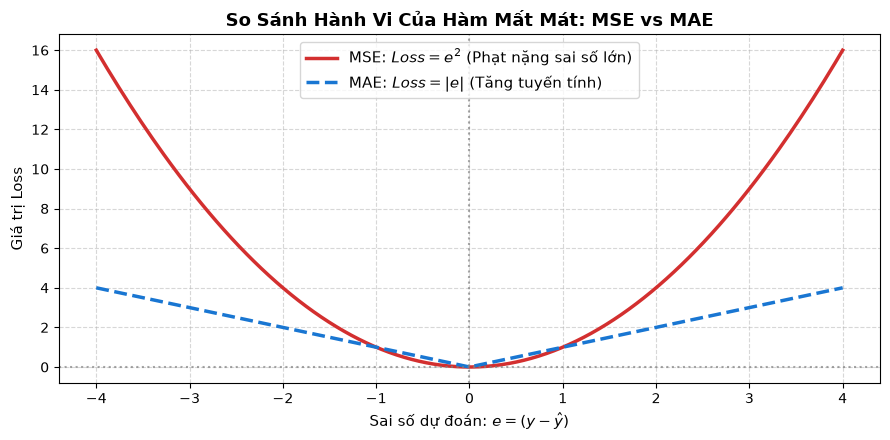

In [8]:
# Minh họa công thức tính MSE, MAE và trực quan hóa so sánh
import numpy as np
import matplotlib.pyplot as plt
import torch

# Giả lập giá trị thực tế y_true và giá trị dự đoán y_pred
y_true = np.array([100.0, 102.5, 98.0, 105.0, 110.0])
y_pred = np.array([101.0, 101.5, 95.0, 108.0, 110.5])

# 1. Tính toán bằng NumPy thuần
errors = y_true - y_pred
mse_val = np.mean(errors ** 2)
mae_val = np.mean(np.abs(errors))
rmse_val = np.sqrt(mse_val)

print("=== SO SÁNH GIÁ TRỊ CÁC HÀM MẤT MÁT ===")
print(f"Giá trị thực tế y_true : {y_true}")
print(f"Giá trị dự đoán y_pred : {y_pred}")
print(f"Độ lệch errors         : {errors}")
print(f"-> MSE                 : {mse_val:.4f}")
print(f"-> MAE                 : {mae_val:.4f}")
print(f"-> RMSE                : {rmse_val:.4f}\n")

# 2. Kiểm chứng lại bằng PyTorch Loss Functions
mse_loss_fn = torch.nn.MSELoss()
mae_loss_fn = torch.nn.L1Loss()
t_true = torch.tensor(y_true, dtype=torch.float32)
t_pred = torch.tensor(y_pred, dtype=torch.float32)
print(f"PyTorch MSELoss output : {mse_loss_fn(t_pred, t_true).item():.4f}")
print(f"PyTorch L1Loss (MAE)   : {mae_loss_fn(t_pred, t_true).item():.4f}")

# 3. Vẽ biểu đồ so sánh hành vi hàm mất mát khi sai số thay đổi từ -4 đến +4
e_range = np.linspace(-4, 4, 200)
mse_curve = e_range ** 2
mae_curve = np.abs(e_range)

plt.figure(figsize=(9, 4.5))
plt.plot(e_range, mse_curve, label='MSE: $Loss = e^2$ (Phạt nặng sai số lớn)', color='#D32F2F', linewidth=2.5)
plt.plot(e_range, mae_curve, label='MAE: $Loss = |e|$ (Tăng tuyến tính)', color='#1976D2', linewidth=2.5, linestyle='--')
plt.axvline(0, color='gray', linestyle=':', alpha=0.7)
plt.axhline(0, color='gray', linestyle=':', alpha=0.7)
plt.title("So Sánh Hành Vi Của Hàm Mất Mát: MSE vs MAE", fontsize=13, fontweight='bold')
plt.xlabel(r"Sai số dự đoán: $e = (y - \hat{y})$", fontsize=11)
plt.ylabel("Giá trị Loss", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


---
<a id="section-12"></a>
## 12. Lan truyền ngược qua thời gian (Backpropagation Through Time - BPTT)

### 12.1. Bản chất của thuật toán BPTT:
**BPTT** là lan truyền ngược trên mạng RNN đã được **trải phẳng qua $T$ bước**. Một bộ trọng số được dùng chung tại mọi bước; gradient của bộ trọng số đó cộng các đóng góp theo thời gian.

```text
FORWARD:   x_1 -> [h_1] -> [h_2] -> ... -> [h_T] -> Loss L
                         ^                 ^
                        x_2               x_T
BACKWARD:        <------- gradient qua các trạng thái -------
```

---

### 12.2. Vì sao Gradient phải truyền ngược qua nhiều bước thời gian?
Đặt $a_t=W_{xh}x_t+W_{hh}h_{t-1}+b_h$, $h_t=\tanh(a_t)$ và giả sử loss chỉ tính tại đầu ra cuối cùng. Với **vector cột**, ký hiệu $g_t=\nabla_{h_t}L$, $D_t=\operatorname{diag}(1-h_t^2)$:
$$g_t = J_{t+1}^{\mathsf T}g_{t+1},\qquad
g_t=J_{t+1}^{\mathsf T}J_{t+2}^{\mathsf T}\cdots J_T^{\mathsf T}g_T.$$
Đặt $\delta_t=D_tg_t$, gradient của các trọng số dùng chung là:
$$\nabla_{W_{hh}}L=\sum_{t=1}^{T}\delta_t h_{t-1}^{\mathsf T},\qquad
\nabla_{W_{xh}}L=\sum_{t=1}^{T}\delta_t x_t^{\mathsf T},\qquad
\nabla_{b_h}L=\sum_{t=1}^{T}\delta_t.$$
Nếu có loss tại nhiều bước, phải cộng thêm đóng góp trực tiếp của loss tại mỗi bước vào $g_t$.

---

### 12.3. Mấu chốt toán học: Ma trận Jacobian trung gian
Với đúng quy ước vector cột ở Mục 3:
$$J_k=\frac{\partial h_k}{\partial h_{k-1}}
=\operatorname{diag}(1-h_k^2)\,W_{hh}=D_kW_{hh}.$$
**Chuyển vị xuất hiện khi lan truyền gradient cột**: $J_k^{\mathsf T}=W_{hh}^{\mathsf T}D_k$, không phải trong công thức Jacobian ở trên.

Các ma trận nhìn chung không giao hoán, nên không tách tích $D_kW_{hh}$ thành một lũy thừa $W_{hh}$ và một tích riêng các $D_k$. Ta có thể dùng chặn chuẩn:
$$\|g_t\|_2\leq\left(\prod_{k=t+1}^{T}\|J_k\|_2\right)\|g_T\|_2.$$
Tích Jacobian qua nhiều bước có thể làm gradient suy giảm hoặc tăng mạnh; đây là cơ sở phân tích vanishing/exploding gradient.


---
<a id="section-13"></a>
## 13. Vấn đề Biến mất đạo hàm (Vanishing Gradient) và Bùng nổ đạo hàm (Exploding Gradient)

### 13.1. Vanishing Gradient (Đạo hàm biến mất / triệt tiêu)
* **Nguyên nhân**:
  1. $\tanh'(z)=1-\tanh^2(z)\in(0,1]$ và tiến gần 0 khi kích hoạt bão hòa.
  2. Gradient truyền ngược qua tích các Jacobian $J_t=D_tW_{hh}$. Nếu các chuẩn Jacobian được chặn bởi một hằng số nhỏ hơn 1, đóng góp từ các bước xa suy giảm theo cấp số nhân.
* **Hậu quả**:
  * Tín hiệu học từ những bước xa có thể rất nhỏ, khiến việc học phụ thuộc dài hạn khó hơn.
  * Trọng số vẫn được dùng chung và cập nhật từ những bước khác; không có một bộ trọng số riêng bị ngừng cập nhật ở đầu chuỗi.
  * **Không có giới hạn phổ quát 5, 10 hay 20 bước**: khả năng ghi nhớ còn phụ thuộc dữ liệu, trọng số, khởi tạo và tối ưu hóa.

---

### 13.2. Exploding Gradient (Đạo hàm bùng nổ)
* **Nguyên nhân**: Tích các Jacobian có thể khuếch đại một số hướng gradient. Chỉ riêng trị riêng của $W_{hh}$ chưa đủ để kết luận cho RNN phi tuyến, vì còn phụ thuộc $D_t$ và hướng gradient.
* **Hậu quả**: Cập nhật quá lớn có thể gây loss dao động, mất ổn định, thậm chí `NaN` hoặc `Inf`. Không phải mọi dao động loss đều là bằng chứng gradient bùng nổ.

---

### 13.3. Các giải pháp khắc phục trong thực tế:
1. **Gradient Clipping**: Giới hạn chuẩn gradient nhằm giảm các bước cập nhật quá lớn:
   $$g\leftarrow g\frac{\theta}{\max(\theta,\|g\|)}.$$
   Ví dụ PyTorch: `torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)`.
2. **Khởi tạo, learning rate và độ dài cửa sổ**: Lựa chọn bằng validation; không có cấu hình bảo đảm hết vanishing/exploding cho mọi dữ liệu.
3. **LSTM / GRU**: Cơ chế cổng hỗ trợ học phụ thuộc dài hạn; vẫn cần kiểm chứng thực nghiệm. Các notebook 01–04 giữ vanilla RNN để thực hiện yêu cầu bài.

> Biểu đồ dưới đây chỉ mô phỏng tích hệ số vô hướng giả định. Hai đường giảm dùng $\tanh'=0.8$; đường tăng dùng kịch bản riêng $\tanh'=1.0$.


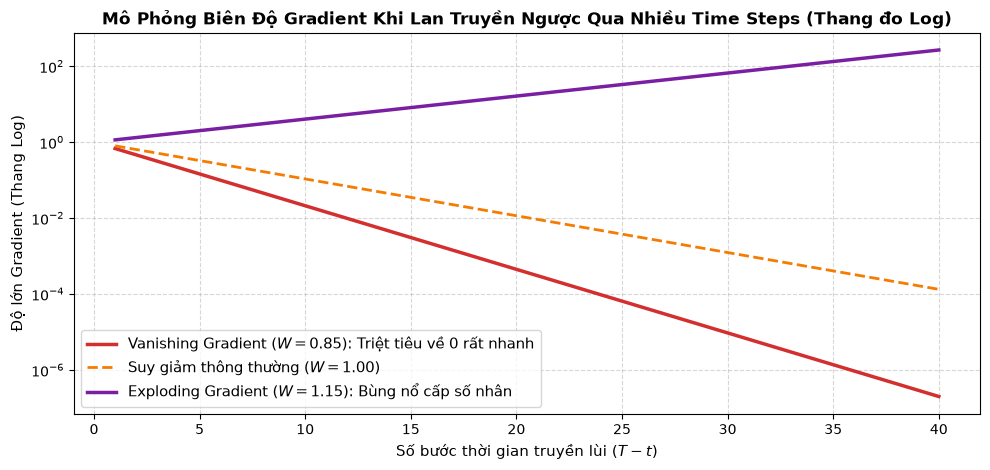

Tại bước thứ 30:
- Gradient trường hợp Vanishing : 9.45e-06 (Nhỏ nhưng khác 0; tín hiệu cập nhật bị suy giảm)
- Gradient trường hợp Exploding : 66.21 (Tăng mạnh trong mô phỏng vô hướng này)
Kiểm chứng Jacobian bằng sai phân hữu hạn: sai số lớn nhất = 3.01e-12


In [9]:
# Mô phỏng trực quan hiện tượng Vanishing Gradient và Exploding Gradient qua 40 bước thời gian
import numpy as np
import matplotlib.pyplot as plt

num_steps = 40
steps = np.arange(1, num_steps + 1)

# Minh họa tích Jacobian vô hướng giả định, không phải gradient đo từ mô hình đã train
w_vanishing = 0.85   # < 1: Triệt tiêu
w_stable    = 1.00   # = 1: Cân bằng lý tưởng
w_exploding = 1.15   # > 1: Bùng nổ

# Giả sử đạo hàm tanh' trung bình là 0.8
tanh_prime = 0.8

# Tính biên độ gradient sau k bước truyền ngược
grad_vanishing = (w_vanishing * tanh_prime) ** steps
grad_stable    = (w_stable * tanh_prime) ** steps
grad_exploding = (w_exploding * 1.0) ** steps  # Kịch bản riêng giả sử tanh' = 1.0

plt.figure(figsize=(10, 4.8))
plt.plot(steps, grad_vanishing, label='Vanishing Gradient ($W=0.85$): Triệt tiêu về 0 rất nhanh', 
         color='#D32F2F', linewidth=2.5)
plt.plot(steps, grad_stable, label='Suy giảm thông thường ($W=1.00$)', 
         color='#F57C00', linewidth=2.0, linestyle='--')
plt.plot(steps, grad_exploding, label='Exploding Gradient ($W=1.15$): Bùng nổ cấp số nhân', 
         color='#7B1FA2', linewidth=2.5)

plt.yscale('log')
plt.title("Mô Phỏng Biên Độ Gradient Khi Lan Truyền Ngược Qua Nhiều Time Steps (Thang đo Log)", 
          fontsize=12, fontweight='bold')
plt.xlabel("Số bước thời gian truyền lùi ($T - t$)", fontsize=11)
plt.ylabel("Độ lớn Gradient (Thang Log)", fontsize=11)
plt.grid(True, which="both", linestyle='--', alpha=0.5)
plt.legend(fontsize=10.5)
plt.tight_layout()
plt.show()

print(f"Tại bước thứ 30:")
print(f"- Gradient trường hợp Vanishing : {grad_vanishing[-11]:.2e} (Nhỏ nhưng khác 0; tín hiệu cập nhật bị suy giảm)")
print(f"- Gradient trường hợp Exploding : {grad_exploding[-11]:.2f} (Tăng mạnh trong mô phỏng vô hướng này)")


# Kiểm chứng Jacobian bằng sai phân hữu hạn trên ma trận không đối xứng.
W_check = np.array([[0.2, -0.4], [0.7, 0.1]])
h_prev_check = np.array([0.1, -0.2])
offset_check = np.array([0.3, -0.1])
h_check = np.tanh(offset_check + W_check @ h_prev_check)
jacobian_formula = np.diag(1 - h_check ** 2) @ W_check
step = 1e-6
jacobian_numeric = np.column_stack([
    (np.tanh(offset_check + W_check @ (h_prev_check + step * e))
     - np.tanh(offset_check + W_check @ (h_prev_check - step * e))) / (2 * step)
    for e in np.eye(2)
])
np.testing.assert_allclose(jacobian_formula, jacobian_numeric, atol=1e-8, rtol=1e-6)
print(f"Kiểm chứng Jacobian bằng sai phân hữu hạn: sai số lớn nhất = {np.max(np.abs(jacobian_formula - jacobian_numeric)):.2e}")


---
<a id="section-14"></a>
## 14. Bảng So Sánh Toàn Diện: RNN vs MLP

Bảng dưới đây tổng hợp các điểm khác biệt bản chất giữa Mạng nơ-ron truyền thẳng (**MLP**) và Mạng nơ-ron tái phát (**RNN**):

| Tiêu chí so sánh | Mạng truyền thẳng MLP (Feedforward) | Mạng nơ-ron tái phát RNN (Recurrent) |
| :--- | :--- | :--- |
| **1. Kiểu dữ liệu phù hợp** | Dữ liệu dạng bảng tĩnh (Tabular), ảnh độc lập, dữ liệu không phụ thuộc trật tự thời gian. | Dữ liệu tuần tự: Chuỗi thời gian (Time-series), văn bản (NLP), tín hiệu âm thanh, video. |
| **2. Bộ nhớ trạng thái (Memory)** | **Không có memory (Stateless)**: Mỗi mẫu dữ liệu được xử lý hoàn toàn tách biệt. | **Có trạng thái ẩn trong chuỗi**: Trạng thái ẩn $h_t$ lưu giữ bản tóm tắt thông tin ngữ cảnh từ các bước trước. |
| **3. Độ dài dữ liệu đầu vào** | **Bắt buộc cố định**: Chiều vector $D$ phải được xác định cứng trước khi khởi tạo mô hình. | **Linh hoạt**: Có thể xử lý các chuỗi có độ dài $T$ thay đổi mà không cần thay đổi kiến trúc mạng. |
| **4. Cơ chế chia sẻ trọng số** | **Không chia sẻ**: Mỗi vị trí node và cạnh kết nối có một trọng số riêng biệt. | **Chia sẻ trọng số (Weight Sharing)**: Cùng một bộ $\{W_{xh}, W_{hh}, W_{hy}\}$ được dùng lặp lại qua mọi bước $t$. |
| **5. Số lượng tham số (Parameters)** | Tăng tuyến tính theo số chiều đầu vào. Nếu ghép chuỗi dài vào vector phẳng, số tham số bùng nổ. | **Độc lập với độ dài chuỗi**: Chuỗi dài 10 bước hay 1000 bước thì số lượng tham số vẫn không đổi. |
| **6. Khả năng tính toán song song** | **Rất cao**: Tất cả các node trong cùng một tầng có thể tính toán song song độc lập trên GPU. | **Bị giới hạn theo thời gian**: Bước $t$ bắt buộc phải chờ tính xong bước $t-1$ (tính toán tuần tự). |
| **7. Ứng dụng tiêu biểu** | Phân loại dữ liệu bảng, định giá nhà đất, dự báo từ các biến trễ đã tạo sẵn. | Dự báo giá chứng khoán, dự báo doanh thu bán lẻ, dịch máy tự động, nhận dạng giọng nói. |


---
<a id="section-15"></a>
## 15. RNN truyền thống vs LSTM và GRU (Sự Tiến Hóa Kiến Trúc)

RNN truyền thống có thể gặp khó khăn khi học phụ thuộc dài hạn do tích Jacobian qua thời gian. LSTM và GRU bổ sung các cổng để hỗ trợ lưu và cập nhật thông tin; không có ngưỡng số bước bảo đảm thành công cho mọi mô hình.

---

### 15.1. Long Short-Term Memory (LSTM - Hochreiter & Schmidhuber, 1997)
LSTM giải quyết vấn đề đạo hàm biến mất bằng cách tách bộ nhớ thành hai thành phần và bổ sung **Cơ chế Cổng (Gating Mechanism)**:
1. **Cell State ($C_t$)**: Cập nhật dạng $C_t=f_t\odot C_{t-1}+i_t\odot\widetilde C_t$. Đường cộng này giúp truyền thông tin, nhưng gradient vẫn phụ thuộc các cổng và có thể suy giảm; không bảo đảm giữ nguyên qua hàng trăm bước.
2. **Hidden State ($h_t$)**: Ký ức ngắn hạn phục vụ cho đầu ra tại bước hiện tại.
3. **Ba cổng điều khiển sử dụng hàm Sigmoid $\sigma(z) \in [0, 1]$**:
   * **Forget Gate ($f_t$)**: Quyết định vứt bỏ bao nhiêu phần trăm thông tin không còn quan trọng trong Cell State cũ $C_{t-1}$.
   * **Input Gate ($i_t$)**: Quyết định cập nhật bao nhiêu phần trăm thông tin mới từ đầu vào $x_t$ vào Cell State.
   * **Output Gate ($o_t$)**: Quyết định trích xuất bao nhiêu phần trăm thông tin từ Cell State để xuất ra Hidden State $h_t$.

---

### 15.2. Gated Recurrent Unit (GRU - Cho et al., 2014)
GRU là một biến thể tinh gọn, hiện đại hóa của LSTM:
* **Hợp nhất Cell State và Hidden State**: Chỉ duy trì một vector trạng thái ẩn duy nhất $h_t$.
* **Giảm xuống còn 2 cổng điều khiển**:
  * **Reset Gate ($r_t$)**: Quyết định mức độ kết hợp giữa thông tin quá khứ và thông tin hiện tại.
  * **Update Gate ($z_t$)**: Đảm nhận đồng thời vai trò của cả Forget Gate và Input Gate trong LSTM.
* **Ưu thế**: Ở cùng kích thước ẩn, GRU thường có ít tham số hơn LSTM. Tốc độ và mức overfitting phải được đo trên cùng dữ liệu, không thể khẳng định chỉ từ số cổng.

---

### 15.3. Bảng tóm tắt so sánh nhanh:
| Tiêu chí | Vanilla RNN | LSTM | GRU |
| :--- | :--- | :--- | :--- |
| **Số lượng trạng thái bộ nhớ** | 1 vector ($h_t$) | 2 vector ($h_t$ và $C_t$) | 1 vector ($h_t$) |
| **Số cổng điều khiển (Gates)** | 0 cổng | 3 cổng (Forget, Input, Output) | 2 cổng (Reset, Update) |
| **Khả năng nhớ chuỗi dài** | Có thể khó học phụ thuộc dài hạn | Cổng và cell state hỗ trợ giữ thông tin | Cổng hỗ trợ giữ và cập nhật thông tin |
| **Số lượng tham số mô hình** | Thấp nhất | Cao nhất (gấp $\approx 4$ lần RNN) | Trung bình (gấp $\approx 3$ lần RNN) |
| **Tốc độ huấn luyện** | Ít phép toán mỗi bước ở cùng kích thước ẩn | Nhiều phép toán mỗi bước hơn | Thường ít phép toán hơn LSTM; tốc độ thực tế tùy backend |


---
<a id="section-16"></a>
## 16. Summary: What I need to remember before implementing RNN on real datasets

Trước khi chuyển sang **Notebook 01** để xây dựng mô hình thực chiến trên hai tập dữ liệu thực tế (**S&P 500 Stock Prices** và **Online Retail Transactions**), hãy ghi nhớ **6 nguyên tắc vàng** sau đây:

---

### 1. Vai Trò Của Chuẩn Hóa Dữ Liệu (Feature Scaling)
* Với $\tanh$, kích hoạt phụ thuộc tổng tuyến tính $Wx+b$; tổng này quá lớn có thể làm đạo hàm bão hòa. Chuẩn hóa giúp kiểm soát thang đo, không phải điều kiện bắt buộc về mặt toán học.
* Trong bài này, dùng `MinMaxScaler` riêng cho từng đặc trưng để giảm chênh lệch thang đo giữa giá, volume và doanh số.
* **Nguyên tắc chống rò rỉ dữ liệu (Data Leakage)**: Luôn chỉ dùng lệnh `.fit()` trên tập **Train**, sau đó áp dụng `.transform()` lên tập **Validation** và **Test**!

### 2. Định Dạng 3D Tensor Của Input
* Với các mini-batch trong bài này, đầu vào được biểu diễn bằng **3D Tensor**:
  $$\text{Shape} = (\text{batch\_size}, \text{sequence\_length}, \text{input\_size})$$
* Sliding window là cách tạo mẫu cho bài dự báo này; không phải mọi bài toán RNN đều cần cửa sổ trượt.

### 3. Quy Ước `batch_first=True` Trong PyTorch
* PyTorch có lịch sử thiết kế mặc định là `(sequence_length, batch_size, input_size)`.
* Để đồng nhất với tư duy trực quan và tương thích với NumPy/Keras, hãy luôn khai báo rõ ràng tham số:
  ```python
  nn.RNN(input_size=..., hidden_size=..., batch_first=True)
  ```

### 4. Cấu Hình Output Trong Bài Toán Hồi Quy (One-Step-Ahead Forecasting)
* Khi dự đoán một giá trị tiếp theo tại bước $T+1$ từ chuỗi $T$ bước trong quá khứ:
  * Trong **PyTorch**: Lấy hidden state ở bước cuối cùng: `h_T = out[:, -1, :]`, sau đó đưa qua lớp `nn.Linear(hidden_size, 1)`.
  * Trong **Keras**: Đặt `return_sequences=False` ở tầng RNN cuối cùng trước khi nối vào lớp `Dense(1)`.

### 5. Lựa Chọn Hàm Mất Mát & Thước Đo Đánh Giá
* **Hàm mất mát huấn luyện (Loss Function)**: Bài chọn MSE để phạt bình phương sai số. Loss trơn không bảo đảm mạng phi tuyến hội tụ tới nghiệm tốt nhất.
* **Thước đo đánh giá thực tế (Evaluation Metrics)**: Sử dụng **MAE** và **RMSE** sau khi đã nghịch đảo chuẩn hóa (`inverse_transform`) để đưa sai số về đơn vị đo lường thực tế của bài toán (USD hoặc Doanh số).

### 6. Cảnh Giác Với Vanishing Gradient
* Cửa sổ dài làm tăng số bước truyền gradient; tác động đến kết quả phải được đánh giá bằng validation, không có ngưỡng cố định `window_size > 20`.
* Các notebook 01–04 triển khai **vanilla RNN** bằng PyTorch và Keras. LSTM/GRU ở đây là kiến thức mở rộng, chưa được thực nghiệm trong bài.

---
**Chúc mừng bạn đã hoàn thành Notebook 00! Bạn đã sẵn sàng bước vào Notebook 01 để xây dựng mô hình thực chiến.**
